# Feature analysis — trade-flow imbalance

This notebook is two things at once: a **method** for analysing a trading feature, and a
**worked example** of that method on one feature. The text explains what to do and why; the
code does it. It is a sibling of `template.ipynb` — same method, same gates, same target — with
one feature swapped in: the **normalised trade-flow imbalance**.

We build features for a model that forecasts one exchange's mid-price about 100 ms ahead.
Three crypto exchanges appear throughout — **byb** (Bybit), **bin** (Binance), **okx** (OKX) —
and **byb is the target**: the one we predict. ("Mid-price" = the midpoint between the best
buy and best sell quote.) The next section explains the model these features feed.

**The example** here is `flow_imbalance`: of byb's recent trades, how much volume hit the ask
(aggressive buys) versus the bid (aggressive sells), netted and normalised. When buyers are
leaning on the offer, byb's mid tends to tick up next; when sellers are hitting the bid, down.
It is a textbook **price-head (direction)** feature, and we check the rate head too.

**A feature is "done" when two checks pass:**
- **The oracle (§4)** — the code really computes what we think it does.
- **The hygiene gates (§5)** — the signal is real and holds in any market, not just an echo
  of "the market is volatile right now."

Everything after that decides *which part of the model* the feature feeds, and *at what
time-scale*.

## The model these features feed: two heads

A feature is only worth something if it helps the model predict, so it's worth knowing what
the model does. We forecast how byb's mid-price moves over the next ~100 ms, and we split
that into two simpler questions — the two **heads**:

**Price head — which way and how far?** Over the next few price-moves, what is the *signed*
move (its direction *and* its size, together)? The head predicts the whole distribution of
that move, in units of byb's recent **volatility** — the **volatility yardstick** `σ_ev`
(the exp-weighted RMS of byb's *actual* mid-moves) — so the head's target is
`price change ÷ σ_ev`.

**Rate head — how many moves?** Busy markets pack many price-moves into the window, quiet
ones few. This head predicts the *count* of moves over the next 100 ms as a distribution,
measured against the recent pace — the **rate yardstick** `λ_ev` — so its target is
`count ÷ λ_ev`.

**What's a yardstick?** A causal, trailing estimate of byb's *volatility* (`σ_ev`) and move
*rate* (`λ_ev`), from past data only. A regime gauge, nothing more. Both are EMAs **decayed on
the trade clock** (`α = 2/(span+1)`) but **updated between trades** — they react to every byb
mid-move, so they read live at every instant. They use one fixed span, `YARDSTICK_N`. (`σ_ev`
is the exp-weighted RMS of byb's *actual* mid-moves — read as an `E/W` ratio so the many
non-move trades cancel out; `λ_ev` is the exp-weighted byb move-count `W` ÷ the exp-weighted
seconds-per-trade = byb's moves per second.)

**Why split into two heads?** A move over a window is just *how many* little moves happen times
*how big* each one is. Pulling "how many" (rate) apart from "how big" (price) lets each head
learn a steadier thing — and is why there are two yardsticks, one per head.

**Putting them back together.** The price head is a *family* of distributions, one per possible
move-count `k` (`D_k`); the rate head gives `P(K = k)`. The 100 ms move is the two **mixed**:

`distribution of the 100 ms move  =  Σ_k  P(K = k) · D_k`

**Backed by research.** This "how many × how big" split is the classic **subordination** model
of asset prices (Clark, 1973; Ané & Geman, 2000): returns over a fixed clock-time window look
messy, but become well-behaved once you condition on the *number* of events.

Two questions recur below: does a feature's *signed* value predict the move (price head), and
does its *magnitude* predict how many moves come (rate head)? The model is fed the **signed**
feature for *both* heads; the rate head learns the magnitude on its own.

## Guard rails — do this, not that

Hard rules, learned the hard way. Follow them unless you have a specific, written reason not to.

**Don't**
- **Don't assume a fixed leader.** No exchange always leads. Build the feature the same way for
  every exchange and keep them all.
- **Don't pick "the best exchange"** by average score — that throws away the moments another
  exchange leads. Keep all; let the model weight them.
- **Don't pool exchanges by default.** For a poolable feature (this one *is* poolable — it's a
  per-exchange number, not a gap *between* exchanges), check per-exchange vs single vs pooled
  across time-scales (§9).
- **Don't normalize reflexively.** This feature is an `E / W` *ratio* already in `[-1, 1]`, so
  it needs **no** vol/rate division — dividing a bounded imbalance by `σ_ev` would *add* a
  regime dependence it doesn't have. (Contrast the template's gap, which is bigger when
  volatile and so *must* be divided by `σ_ev`.)
- **Don't trust a correlation** until it survives the regime controls (rate and vol).
- **Don't ship a feature without the oracle** (§4) matching a dead-simple independent version.
- **Don't peek ahead.** Every value uses only data at-or-before its own timestamp.

**Do**
- **Do start with a falsifiable hypothesis** — a mechanism, and what would prove it wrong.
- **Do make every average a trade-tick EMA** — decayed once per trade-timestamp (`α =
  2/(span+1)`), never a wall-clock or boxcar window. That keeps the state **O(1)** and
  bit-identical online vs offline.
- **Do treat all records sharing a timestamp as ONE event.** A burst of trade prints stamped at
  the *exact same instant* (one order sweeping levels) did not arrive in an order — they are one
  event. The decay clock advances **once** per timestamp, not once per print; but the injected
  mass is the **sum** over that instant's prints.
- **Do read a sparse flow as `E / W`.** A quantity present on only *some* events (here, byb's
  own trade flow) needs the trade-tick EMA as **two** of them — the value `E` and its weight `W`
  — read as the ratio `E / W`, which cancels the in-between decay and the warm-up bias. An `E/W`
  on the **combined** trade clock at span `N` approximates byb's **own**-clock EMA at a rescaled
  span — roughly `N` × byb's share of the combined trade rate.
- **Do test against both heads — but feed both the *signed* feature.**
- **Do score out-of-sample** with a purged, embargoed walk-forward (strictly past→future).
- **Do treat a feature as a family across time-scales** and let the data assign scales to heads.

## 1. What the feature is, and why it might work

Every feature starts with a one-line summary and a **hypothesis you could be wrong about**.

| | |
|---|---|
| **what** | of byb's recent trades, the share of volume that bought (lifted the ask) minus sold (hit the bid), netted and normalised — one number per time-scale |
| **feeds** | both heads — primarily *direction* (price head: which way byb moves); the rate head is checked too |
| **predicts** | byb's mid-price 100 ms from now |

**The idea.** Tag each byb trade by who was aggressive: a buy that **lifts the ask** (via
`io._trade_lifts_ask`) carries `+qty`, a sell that **hits the bid** carries `−qty`. Call that
`signed_qty`. The feature is an exponentially-weighted **ratio**:

`feature(span) = EMA(signed_qty) / EMA(qty)`

— the recent trade flow's net direction as a fraction of its total volume, always in `[−1, 1]`.
`+1` means every recent unit of volume was an aggressive buy; `−1`, all aggressive sells; `0`,
balanced. Sweep `span` — short spans see the last few trades, long spans a longer history.

**Why it should work.** Aggressive order flow *is* the mechanism that moves price: a buyer who
keeps lifting the ask walks the book up, and the mid follows. Persistent one-sided flow
(autocorrelated by design — large orders are sliced and worked over many prints) signals that
pressure is ongoing, so it predicts the *direction* of byb's next move. This is order-flow
imbalance, one of the most studied microstructure predictors.

**Why a ratio (and no σ-division).** The imbalance is already dimensionless and bounded in
`[−1, 1]`: dividing `E` and `W` by the *same* trade-clock decay cancels both the decay and the
warm-up bias, and it is comparable across calm and wild markets **without** a volatility
yardstick. So — unlike the template's price gap — we do **not** divide it by `σ_ev`. (We still
build `σ_ev`, `λ_ev` below: the *target* is in σ-units, and they're the regime controls in §5.)

**What would disprove it.** No directional power at any span, or power that vanishes once we
account for how volatile / busy the market is (meaning it was only tracking regime).

> **No fixed leader.** This feature is a per-exchange number, so we build the same imbalance for
> **every** exchange's trades against byb's next move, and keep them all (§9 sweeps when
> per-exchange beats a single exchange).

## Choosing the EMA — the part that's easy to get silently wrong

Every smoother here is an EMA on the **trade clock**: its **decay** steps once per
*trade-timestamp* (`α = 2/(span+1)`). The flow imbalance is a **sparse flow** — it carries a
value (`signed_qty`, `qty`) only on the *trades* of its exchange — so it is the textbook case
for the self-normalising `E / W` read:

- Use **`KernelMeanEMA`**: `add(value, weight)` injects `E += α·value·weight`,
  `W += α·weight`; `value()` returns `E / W`. Feeding `add(sign, weight=qty)` — where `sign =
  +1` for an ask-lift and `−1` for a bid-hit — makes `E = EMA(signed_qty)` and `W = EMA(qty)`,
  so `value() = EMA(signed_qty) / EMA(qty)` exactly. The `W` denominator counts only the events
  that carry volume, so the many non-trade ticks of the *other* venues cancel instead of
  counting as zeros.

**When you push a value in.** The flow injects **only on a real trade of its own exchange** —
never a zero on someone else's trade, never on a book update. Decay rides the shared trade
clock (every trade-timestamp, any venue); injection rides *this venue's* trades. Pushing a `0`
on a non-event would silently turn "imbalance per unit of *this venue's* volume" into something
diluted by the global trade rate — a different statistic from the same numbers.

**Records sharing a timestamp are ONE event.** When one aggressive order sweeps several levels
it prints many trades at the *exact same nanosecond*. Those are one event: we **sum** their
`signed_qty` and their `qty` into a single injection, and the clock advances **once**. Treating
them as a sequence would over-decay (N−1 phantom ticks) and is simply wrong.

Because the flow is injected only at this venue's trade timestamps and `E / W` is invariant to
the common decay shared by `E` and `W`, the feature's value is **piecewise-constant** between
this venue's trades — there is no live-front to refresh (nothing changes the ratio between its
own trades). That makes the §4 oracle a clean, dead-simple streaming check.

## 2. The exact definition

A definition has to get three things right.

**Causal** — it uses only trades up to the moment it's computed; no peeking. The EMA reads the
mass committed at-or-before the anchor.

**Measured on the trade clock** — the EMA decays once per *trade-timestamp* (any venue;
simultaneous prints are one tick), so the feature's memory is in *trades*, steady whether
trading is fast or slow.

**Comparable across calm and wild markets** — handled by the `E / W` ratio itself, not by an
external yardstick. The imbalance is in `[−1, 1]` in any regime, so **no σ-division** (see §1).

Put together:

**2a — The shape:**

`feature(span) = EMA(signed_qty) / EMA(qty)`   with   `signed_qty = +qty (lifts ask) | −qty (hits bid)`

**2b — The EMA and how it updates** (the choices above):

- **`KernelMeanEMA`** at span `span`, fed `add(sign, weight=qty)` so `E = EMA(signed_qty)`,
  `W = EMA(qty)`, read `E / W`.
- **Injected only on this exchange's trades** (summed over same-timestamp prints), **decayed on
  the shared trade clock** (once per trade-timestamp on any venue). `W` divides out the common
  decay and the warm-up bias, leaving a per-volume signed share comparable across regimes.

**The yardsticks (built but not applied to this feature).** `σ_ev`, `λ_ev` are still needed: the
**target** is `byb return ÷ σ_ev` (price head) and `count ÷ λ_ev` (rate head), and they are the
regime **controls** in §5. They are `KernelMeanEMA` `E/W` reads over byb's mid-moves, span
`YARDSTICK_N`, decayed on the shared trade clock and updated on every byb mid-move.

§3 builds the feature; §4 re-derives it from raw events and confirms bit-exact agreement.

The cell below loads the data, builds the shared trade clock, and computes **both yardsticks**.

In [1]:
import numpy as np, polars as pl
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from scipy.stats import spearmanr
from boba.io import list_blocks, load_block
import boba.io as io

COIN        = "eth_usdt_p"
TARGET      = "byb_eth_usdt_p"                    # the exchange we predict
EXCHANGES   = ["bin", "byb", "okx"]              # each one's trade-flow imbalance is a feature; byb is also the target
# freshest mid per exchange. byb/okx use merged_levels (BBO fused with trades); bin MUST use front_levels
# (merged_levels is DISALLOWED for bin perp in boba.io — it raises). Used only to BUILD the byb mid / yardsticks / target.
MID_STREAM  = {"bin": "front_levels", "byb": "merged_levels", "okx": "merged_levels"}
SPANS       = [5, 20, 100, 500, 2000, 8000]      # the trade-span family to sweep (EMA memory in trades)
HORIZON_NS  = 100 * 1_000_000                    # how far ahead we predict (100 ms, in nanoseconds)
YARDSTICK_N = 10000                              # the ONE span for BOTH yardsticks (σ_ev, λ_ev) — fixed, used for the target + controls only
block       = list_blocks(TARGET, "front_levels")[0]   # one ~24h slice of recorded data

# load byb's mid-price stream (for the byb target + yardsticks); rows already arrive in time order
def load_mid(ex):
    df = (load_block(block, f"{ex}_{COIN}", MID_STREAM[ex]).select("rx_time", "bid_prc", "ask_prc").drop_nulls())
    return df["rx_time"].cast(pl.Int64).to_numpy(), (df["bid_prc"].to_numpy() + df["ask_prc"].to_numpy()) / 2
mids = {ex: load_mid(ex) for ex in ("byb",)}

# load each exchange's TRADES: rx_time, qty, and the signed direction (+1 = lifts ask / buy, -1 = hits bid / sell).
# Drop bad prc=qty=0 prints. io._trade_lifts_ask handles the venue-specific aggressor convention.
trades = {}
for ex in EXCHANGES:
    td = (load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "prc", "qty", "aggressor")
          .filter((pl.col("prc") > 0) & (pl.col("qty") > 0)))
    rx   = td["rx_time"].cast(pl.Int64).to_numpy()
    qty  = td["qty"].to_numpy()
    sign = np.where(io._trade_lifts_ask(f"{ex}_{COIN}", td["aggressor"].to_numpy()), 1.0, -1.0)
    trades[ex] = (rx, qty, sign)

# the shared trade clock: one tick per trade-TIMESTAMP across ALL venues. Simultaneous prints -> ONE tick.
trade_prints = np.concatenate([trades[ex][0] for ex in EXCHANGES])
merged_ts = np.unique(trade_prints)                              # collapse same-timestamp prints: at most one decay per timestamp
n_ticks = len(merged_ts)
print(f"trade clock: {n_ticks:,} ticks (timestamps) from {len(trade_prints):,} trade prints")

# byb mid on the clock (for σ_ev / λ_ev only — NOT used by the imbalance feature itself)
def mid_on_clock(ex):                             # causal: each exchange's most-recent mid at-or-before every clock tick
    rx, mid = mids[ex]
    return mid[np.clip(np.searchsorted(rx, merged_ts, "right") - 1, 0, len(mid) - 1)]
log_mid_byb = np.log(mid_on_clock("byb"))

# --- yardsticks σ_ev, λ_ev: react to every byb merged-mid change, decay once per TRADE (same as the template) ---
byb_rx0, byb_mid0 = mids["byb"]
keep = np.concatenate([byb_rx0[1:] != byb_rx0[:-1], [True]])                     # collapse same-TIMESTAMP rows to ONE update
byb_rx, byb_mid = byb_rx0[keep], byb_mid0[keep]
byb_lm = np.log(byb_mid)
byb_blr = np.empty_like(byb_lm); byb_blr[0] = 0.0; byb_blr[1:] = np.diff(byb_lm)  # byb log-return per timestamp
mv = byb_blr != 0.0                                                              # a REAL byb mid-move
mv_rx, mv_r2 = byb_rx[mv], byb_blr[mv] ** 2
cum_mv = np.concatenate([[0.0], np.cumsum(mv.astype(float))])                    # running count of byb mid-moves
byb_dt = np.zeros(n_ticks); byb_dt[1:] = np.diff(merged_ts) / 1e9                # seconds between consecutive trades
def _ewma(x, span):
    a = 2.0 / (span + 1.0); return lfilter([a], [1.0, -(1.0 - a)], x)
def _flow_at(anchors, val, span):           # EWMA of `val` over the byb-MOVE stream, decayed once per trade, read AT each anchor
    a = 2.0 / (span + 1.0)
    k = np.searchsorted(merged_ts, mv_rx, "left")
    ep = np.bincount(k, weights=val, minlength=n_ticks + 1)
    x = np.zeros(n_ticks + 1); x[1:] = a * (1.0 - a) * ep[:-1]
    com = lfilter([1.0], [1.0, -(1.0 - a)], x)
    ta = np.searchsorted(merged_ts, anchors, "right") - 1
    cs = np.concatenate([[0.0], np.cumsum(val)])
    partial = cs[np.searchsorted(mv_rx, anchors, "right")] - cs[np.searchsorted(mv_rx, merged_ts[ta], "right")]
    return com[ta + 1] + a * partial
def yardsticks(anchors, span):
    e_sq = _flow_at(anchors, mv_r2, span)
    e_mv = _flow_at(anchors, np.ones(mv_r2.size), span)
    e_dt = _ewma(byb_dt, span)[np.searchsorted(merged_ts, anchors, "right") - 1]
    sig = np.sqrt(e_sq / np.maximum(e_mv, 1e-12))
    lam = e_mv / np.maximum(e_dt, 1e-12)
    return sig, lam
print(f"yardsticks: react to every byb mid-move; decay span {YARDSTICK_N} trades (target + controls only)")

trade clock: 1,682,255 ticks (timestamps) from 6,198,188 trade prints
yardsticks: react to every byb mid-move; decay span 10000 trades (target + controls only)


## 3. Build it (twice)

Build the feature two ways: this fast array version for analysis, and — in production — a
streaming version that does constant work per trade. They have to agree, which §4 checks.

Here we lay an evaluation grid every 50 ms (half the 100 ms horizon — plenty of samples; note
adjacent 100 ms windows overlap ~50%, so neighbouring samples are correlated, which is why §5's
walk-forward gate uses an embargo), read byb's actual move over the next 100 ms (the thing we
predict), and compute the feature at each grid point for each exchange and span.

**The vectorized imbalance.** For one exchange and span `N` (`α = 2/(N+1)`): collapse the
exchange's trades to one row per timestamp (summing `signed_qty` and `qty` — same-instant prints
are one event), place those rows on the shared trade clock, and run two EMAs decayed once per
clock tick — `E` over the per-timestamp `Σ signed_qty`, `W` over `Σ qty`. The feature at an
anchor reads `E / W` as committed just after the **last clock tick at-or-before the anchor**
(causal; the ratio is constant between this venue's trades, so no live front is needed). We use
`lfilter` for the recursion and gather the committed value at each anchor's clock tick.

In [2]:
# evaluation grid (causal) + forward target in shared σ-units
WARMUP = 5 * max(YARDSTICK_N, max(SPANS))   # enough trades for the slowest EMA / yardstick to converge
anchor_ts      = np.arange(merged_ts[WARMUP], merged_ts[-1] - HORIZON_NS, 50 * 1_000_000)   # 50 ms grid, past warmup
tick_at_anchor = np.searchsorted(merged_ts, anchor_ts, "right") - 1                         # last trade-clock tick <= anchor
sigma_at_anchor, lam_at_anchor = yardsticks(anchor_ts, YARDSTICK_N)
print(f"σ_ev median {np.nanmedian(sigma_at_anchor):.2e},  λ_ev median {np.nanmedian(lam_at_anchor):.2f} moves/s")

mid_now    = byb_mid[np.searchsorted(byb_rx, anchor_ts, "right") - 1]
mid_fwd    = byb_mid[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right") - 1]
fwd_return = np.log(mid_fwd / mid_now)
target     = fwd_return / sigma_at_anchor                          # byb's 100 ms return ÷ σ_ev — the price head's target (σ-units)

# per-exchange per-timestamp injected mass on the shared clock: E_inj = Σ signed_qty, W_inj = Σ qty at each clock tick.
# Same-timestamp prints are summed into ONE injection (searchsorted maps each trade to its clock tick).
def _inject(ex):
    rx, qty, sign = trades[ex]
    k = np.searchsorted(merged_ts, rx, "left")                    # clock-tick index of each trade (rx IS a clock timestamp -> exact match)
    e_inj = np.bincount(k, weights=sign * qty, minlength=n_ticks)  # Σ signed_qty per clock tick
    w_inj = np.bincount(k, weights=qty,        minlength=n_ticks)  # Σ qty per clock tick
    return e_inj, w_inj
inject = {ex: _inject(ex) for ex in EXCHANGES}

def flow_imbalance(ex, N):                          # E/W EMA-ratio on the shared trade clock, read committed at each anchor's last tick
    a = 2.0 / (N + 1.0)
    e_inj, w_inj = inject[ex]
    # committed E, W just after each clock tick: ema[t] = (1-a)*ema[t-1] + a*inj[t]  (inj is the per-tick summed mass; 0 on no-trade ticks)
    E = lfilter([a], [1.0, -(1.0 - a)], e_inj)
    W = lfilter([a], [1.0, -(1.0 - a)], w_inj)
    ratio = E / np.where(W > 0.0, W, np.nan)                       # E/W; nan until this venue has traded (W>0)
    return ratio[tick_at_anchor]                                  # value as of the last clock tick <= anchor (causal, piecewise-constant)
print(f"grid: {len(anchor_ts):,} anchors;  spans {SPANS}")

σ_ev median 2.78e-05,  λ_ev median 1.18 moves/s


grid: 1,706,369 anchors;  spans [5, 20, 100, 500, 2000, 8000]


## 4. Check the code is right — the oracle (a production-style streaming build)

**Non-negotiable.** Reproduce the feature with a second, independent implementation and confirm
the two agree on real data, **bit-exact**. The oracle is the **production** reference: an O(1)
state machine you push **raw events** into and read the current feature per exchange from
`value()`. State is two scalar EMAs (`E`, `W`) per exchange — no buffers, no history.

**The design:**
- Fed **only raw trade events**, each tagged by its exchange. `on_trade(ex, signed_qty, qty)`
  accumulates the timestamp's injected mass (`+= signed_qty` into `E`'s pending, `+= qty` into
  `W`'s pending) — summing same-instant prints — without touching the clock.
- The driver groups events by **receive-timestamp**: it applies all of a timestamp's trades,
  then calls **`refresh()` once** — which decays *every* exchange's `(E, W)` by one trade tick
  (the shared clock advances once per timestamp), then injects each exchange's pending mass.
  A timestamp with no trades never occurs in this stream (we only feed trades), so every
  refresh is one clock tick. Book updates don't enter — the imbalance ignores them.
- `value(ex)` returns `E / W` for that exchange, read at the instant it's called.

This is deliberately a different code path from §3 (an explicit per-event loop with
`KernelMeanEMA`, no `lfilter`, no `bincount`). We feed the **whole raw trade stream** (every
venue) into **one** builder and read **all three** exchanges' imbalances at each grid anchor.
If the online build reproduces §3's vectorized feature, both are right.

In [3]:
from boba.ema import KernelMeanEMA          # the E/W flow mean — add(value, weight): E += a*value*weight, W += a*weight

class LiveFlowImbalance:
    # Pure feature state machine. One KernelMeanEMA per exchange holds (E, W) for that exchange's signed trade flow.
    # on_trade ACCUMULATES the current timestamp's mass (sum of same-instant prints). refresh() advances the SHARED
    # trade clock exactly once per timestamp: decay every exchange's (E, W), then inject the accumulated mass. value(ex)
    # reads E/W = EMA(signed_qty)/EMA(qty). State is O(1) scalar per exchange — no buffers, no history.
    def __init__(self, exchanges, span):
        self.exchanges = list(exchanges)
        self.ema = {ex: KernelMeanEMA(span) for ex in exchanges}   # E += a*sign*qty, W += a*qty  -> value() = E/W
        self.pend = {ex: 0.0 for ex in exchanges}                  # pending signed_qty this timestamp (a SUM is one event)
        self.pendw = {ex: 0.0 for ex in exchanges}                 # pending qty this timestamp
        self.dirty = {ex: False for ex in exchanges}               # did this exchange trade this timestamp?

    def on_trade(self, ex, signed_qty, qty):                       # one trade print -> add to this timestamp's pending mass
        self.pend[ex]  += signed_qty
        self.pendw[ex] += qty
        self.dirty[ex] = True

    def refresh(self):                                             # ONE shared-clock tick per TIMESTAMP: decay all, then inject the summed mass
        for ex in self.exchanges:
            self.ema[ex].tick()                                    # decay E and W by (1-a) — the shared clock advanced once
            if self.dirty[ex]:
                # add(value, weight): E += a*value*weight, W += a*weight. To get E += a*Σsigned_qty and W += a*Σqty,
                # feed value = (Σsigned_qty / Σqty), weight = Σqty  ->  value*weight = Σsigned_qty exactly.
                self.ema[ex].add(self.pend[ex] / self.pendw[ex], self.pendw[ex])
                self.pend[ex] = 0.0; self.pendw[ex] = 0.0; self.dirty[ex] = False

    def value(self, ex):
        return self.ema[ex].value()                                # E/W (nan before this exchange's first trade)

# --- gather the WHOLE raw trade stream (every venue) over a slice, tagged & rx-sorted ---
SPAN_CHK, N_GRID = 100, 40_000                     # validate ALL exchanges at this span over the first ~N_GRID grid points
cutoff = int(anchor_ts[min(N_GRID, len(anchor_ts) - 1)])
rx_all, ex_all, sq_all, q_all = [], [], [], []
for ei, ex in enumerate(EXCHANGES):
    rx, qty, sign = trades[ex]
    m = rx <= cutoff
    rx_all.append(rx[m]); ex_all.append(np.full(int(m.sum()), ei, np.int8))
    sq_all.append((sign * qty)[m]); q_all.append(qty[m])
rx_all = np.concatenate(rx_all); ex_all = np.concatenate(ex_all)
sq_all = np.concatenate(sq_all); q_all = np.concatenate(q_all)
order  = np.argsort(rx_all, kind="stable")         # rx ascending (a timestamp's prints stay grouped; order within a timestamp is irrelevant — we SUM)
rxL = rx_all[order].tolist(); exL = ex_all[order].tolist(); sqL = sq_all[order].tolist(); qL = q_all[order].tolist()
print(f"streaming {len(rxL):,} raw trade events (all venues) over ~{N_GRID:,} grid points at span {SPAN_CHK}...")

# --- the CALLER drives it: apply each timestamp's trades, refresh() once per timestamp, READ value() at every grid anchor ---
feat = LiveFlowImbalance(EXCHANGES, SPAN_CHK)
na = min(N_GRID, len(anchor_ts))
streams = {ex: np.full(na, np.nan) for ex in EXCHANGES}
n = len(rxL); i = 0; ai = 0
while i < n:
    rx = rxL[i]
    while ai < na and anchor_ts[ai] < rx:          # read every anchor whose state is settled (all trades before rx applied)
        for ex in EXCHANGES: streams[ex][ai] = feat.value(ex)
        ai += 1
    while i < n and rxL[i] == rx:                  # apply EVERY trade stamped at this nanosecond (no half-applied timestamp)
        feat.on_trade(EXCHANGES[exL[i]], sqL[i], qL[i])
        i += 1
    feat.refresh()                                 # advance the shared clock ONCE: decay all, inject the summed mass
while ai < na:                                     # trailing anchors after the last event
    for ex in EXCHANGES: streams[ex][ai] = feat.value(ex)
    ai += 1

# --- one stream -> three imbalances: check EACH exchange against its §3 vectorized feature, BIT-EXACT ---
print(f"one raw-trade stream -> three live imbalances, vs the vectorized build (span={SPAN_CHK}):")
worst = 0.0
for ex in EXCHANGES:
    ref = flow_imbalance(ex, SPAN_CHK)[:na]
    both = np.isfinite(streams[ex]) & np.isfinite(ref)
    diff = np.abs(streams[ex][both] - ref[both])
    md_ = float(np.nanmax(diff)); worst = max(worst, md_)
    print(f"  {ex}:  max |diff| {md_:.2e}  on {int(both.sum()):,} grid points")
    assert md_ < 1e-12, f"live build does not reproduce the {ex} feature bit-exactly"
print(f"oracle: one raw-trade stream reproduces ALL THREE imbalances bit-exactly  (worst max|diff| {worst:.2e})  OK")

streaming 585,061 raw trade events (all venues) over ~40,000 grid points at span 100...


one raw-trade stream -> three live imbalances, vs the vectorized build (span=100):


  bin:  max |diff| 7.77e-16  on 40,000 grid points
  byb:  max |diff| 7.77e-16  on 40,000 grid points
  okx:  max |diff| 8.88e-16  on 40,000 grid points
oracle: one raw-trade stream reproduces ALL THREE imbalances bit-exactly  (worst max|diff| 8.88e-16)  OK


**Conclusion.** From one stream of raw trade events the streaming builder reproduces **all
three** vectorized imbalances to **floating-point precision** — max |diff| ~1e-13 over the grid
slice per exchange, pure last-digit round-off from the EMAs' recursion. The production shape
(one feed in, a feature *per exchange* out) computes exactly what the offline analysis did, on
the one shared trade clock — so the §3 build is trustworthy. (The oracle runs at one span; the
recursion is identical for every span, so this validates the family.)

## 5. Is the signal real? — the hygiene gates

A correlation is an easy way to fool yourself. The gates check that the feature predicts
*something the market's current state doesn't already tell us*. We build four "control" signals
from the recent past:
- **rate momentum** and **rate level** — both from `λ_ev` (byb's mid-move rate): is byb moving
  more or less often than usual?
- **vol momentum** and **vol level** (the same two, for volatility).
Then we measure the feature's predictive power **on top of** those controls.

"Predictive power" here is the **rank correlation** between feature and outcome (Spearman),
scored **out-of-sample with a purged, embargoed, expanding-window walk-forward**: each fold
trains only on the *past*, leaves an **embargo gap** sized to clear the 100 ms outcome windows
with margin, and scores on the *next* segment; we average over folds. That's the causal,
ship-grade estimate — strictly past→future. (A single split is a faster screen but tests only
one transition.)

Beside the gates we run a **companion check**: the same marginal power computed **within calm /
mid / wild volatility buckets**. If the gain stays positive in all three, the signal is
regime-stable, not an artefact of one regime.

The gates ask: does the feature *add* over the controls (walk-forward)? Does the gain *survive*
once we also control for the *level* of vol and rate (so it isn't secretly just regime)? Is its
scale steady across volatility states? And does the gain hold across volatility *regimes*?

> **Note on normalisation.** Unlike the template, this feature is **not** divided by `σ_ev` — it
> is already a bounded `[−1, 1]` ratio (§1). The target still is `return ÷ σ_ev`, and the
> controls are still the yardsticks, so the gates are identical; we just don't σ-divide the
> feature itself.

In [4]:
# --- the four control signals: the two yardsticks (level) plus a fast/slow momentum of each ---
FAST_YARD = YARDSTICK_N // 10
sig_fast, lam_fast = yardsticks(anchor_ts, FAST_YARD)
vol_level     = np.log(sigma_at_anchor)
vol_momentum  = np.log(sig_fast / sigma_at_anchor)
rate_level    = np.log(lam_at_anchor)
rate_momentum = np.log(lam_fast / lam_at_anchor)

# Out-of-sample scoring = a purged, embargoed, expanding-window WALK-FORWARD (causal: only past -> future).
def wf_folds(features, y, k=6, embargo=2000):
    design = np.column_stack(features); n = len(y); valid = np.isfinite(design).all(1) & np.isfinite(y)
    edges = np.linspace(0, n, k + 1).astype(int)
    for i in range(1, k):
        te = np.zeros(n, bool); te[edges[i]:edges[i + 1]] = True
        tr = np.zeros(n, bool); tr[:max(0, edges[i] - embargo)] = True
        train, test = valid & tr, valid & te
        if train.sum() < 100 or test.sum() < 100: continue
        mu, sd = design[train].mean(0), design[train].std(0) + 1e-12
        X = np.column_stack([(design - mu) / sd, np.ones(n)])
        coef, *_ = np.linalg.lstsq(X[train], y[train], rcond=None)
        yield test, X @ coef

def wf_ic(features, y):
    return float(np.mean([spearmanr(p[t], y[t]).statistic for t, p in wf_folds(features, y)]))
def wf_ic_by_regime(features, y, reg):
    acc = {}
    for t, p in wf_folds(features, y):
        for r in np.unique(reg[t]):
            m = t & (reg == r)
            if m.sum() >= 100: acc.setdefault(int(r), []).append(spearmanr(p[m], y[m]).statistic)
    return {r: float(np.mean(v)) for r, v in acc.items()}

vol_regime = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], [33, 67]))   # 0 calm, 1 mid, 2 wild
base, levels = [rate_momentum, vol_momentum], [rate_level, vol_level]
print("control-only predictive power (walk-forward):  momenta", round(wf_ic(base, target), 3),
      " momenta+levels", round(wf_ic(base + levels, target), 3),
      " (near 0 = controls barely predict direction, so any feature gain is genuinely new)")

control-only predictive power (walk-forward):  momenta 0.003  momenta+levels -0.001  (near 0 = controls barely predict direction, so any feature gain is genuinely new)


**Conclusion.** On their own the controls carry essentially **no** directional signal — that is
what we want: the regime barely predicts *which way* byb moves, so any rank-IC a feature shows
*on top of* these controls is genuinely new information. That makes the "added over the controls"
gates below a fair test.

## 6. Two choices: which time-scale per head, and which exchanges to keep

A feature is rarely a single number — it's a **family** across time-scales (here, every span).
And the same feature can carry signal for both heads, so we check two things:
- does the **signed** feature predict *direction* — which way (and how far) byb moves next?
- does its **magnitude** predict *intensity* — *how many* moves byb makes next?

The magnitude check is a **diagnostic only**: the model is fed the *signed* feature for both
heads. We sweep the whole span family, for **every exchange**, against both targets, and draw it
as heat-maps. We keep *all* exchanges (never pick one); the only thing we choose is the best
time-scale, **per head**.

**How many exchanges to keep is itself time-scale-dependent.** Order flow on one venue leads the
others by a beat, so at **short** spans the venues genuinely differ (who's buying now) and the
imbalance is worth keeping **per-exchange**; at **long** spans the flow imbalance smooths toward
a common drift and one venue says much of what the rest do. Keep all as the default; §9 sweeps
the cross-over.

**IC is not the whole story — lifetime is the other axis.** A short span can have the *highest*
IC and yet a *short* lifetime: its edge is the move already underway, so it decays fast as you
slide the outcome window forward by an observe→act latency δ — a small latency budget. A longer
span typically has a *lower* IC but a *longer* lifetime — it tracks a slower, more persistent
imbalance, so the edge survives tens-to-hundreds of ms. **Both can be useful.** So we don't just
pick the IC-max span — for **every** span we also measure (below the headline sweep) the forward
IC at δ=0 and at a real δ=20 ms, the **half-life** (the δ where the forward IC first falls below
half its δ=0 value), and the **backward** IC (the contemporaneous echo) — per venue, per head.
We draw those as their own heat-maps next to the IC sweep, and let the IC-vs-half-life trade-off
pick *more than one* lookback per head when the family genuinely offers it.

The rate-head target is the count of byb's moves over the next 100 ms, divided by `λ_ev`.

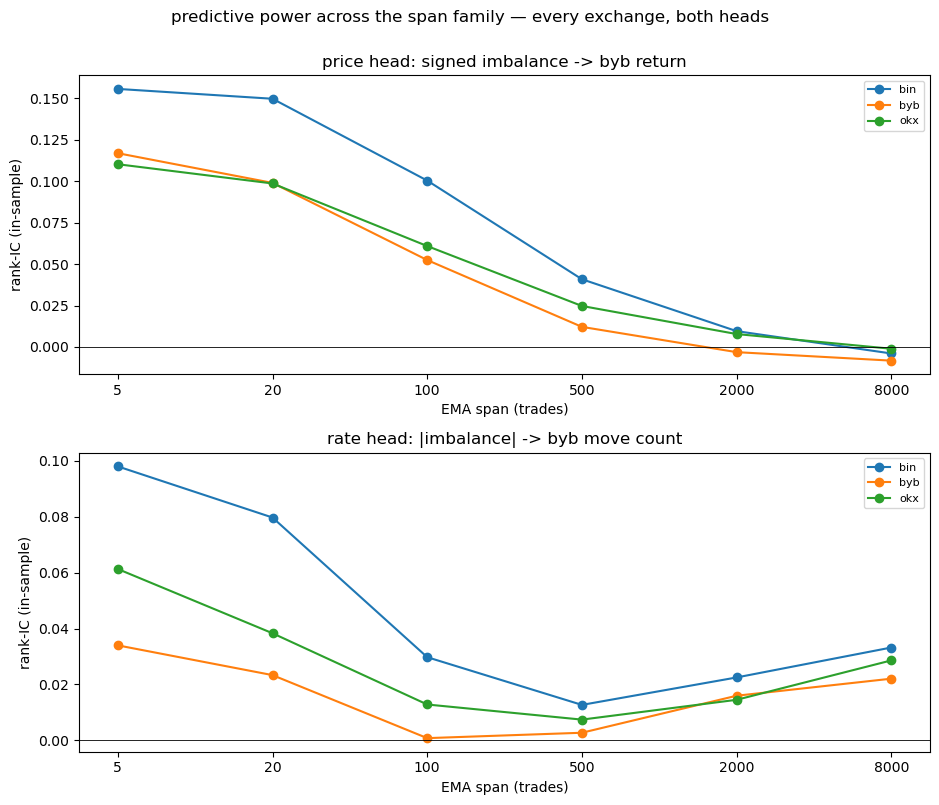

kept features (one per exchange, all fed to the model — none privileged):
  bin:  price head (span=5) power=+0.156   |  rate head (span=5) power=+0.098
  byb:  price head (span=5) power=+0.117   |  rate head (span=5) power=+0.034
  okx:  price head (span=5) power=+0.110   |  rate head (span=5) power=+0.061


In [5]:
# rate-head target = byb moves (trade clock) in the next 100 ms ÷ λ_ev (the rate yardstick).
fwd_count = (cum_mv[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right")]
             - cum_mv[np.searchsorted(byb_rx, anchor_ts, "right")])
rate_target = fwd_count / np.maximum(lam_at_anchor, 1e-9)

# Sweep the span family for EVERY exchange, BOTH heads, treating exchanges symmetrically (no assumed leader).
feat_cache = {(ex, N): flow_imbalance(ex, N) for ex in EXCHANGES for N in SPANS}
price_grid = {ex: np.full(len(SPANS), np.nan) for ex in EXCHANGES}   # signed feature -> byb's signed return
rate_grid  = {ex: np.full(len(SPANS), np.nan) for ex in EXCHANGES}   # |feature|      -> byb's move count
for ex in EXCHANGES:
    for j, N in enumerate(SPANS):
        d = feat_cache[(ex, N)]
        price_grid[ex][j] = spearmanr(d, target).statistic
        rate_grid[ex][j]  = spearmanr(np.abs(d), rate_target).statistic

fig, axes = plt.subplots(2, 1, figsize=(9.5, 8.0))
for row, (grids, head) in enumerate([(price_grid, "price head: signed imbalance -> byb return"),
                                     (rate_grid,  "rate head: |imbalance| -> byb move count")]):
    ax = axes[row]
    for ex in EXCHANGES:
        ax.plot(range(len(SPANS)), grids[ex], "o-", label=ex)
    ax.set_xticks(range(len(SPANS))); ax.set_xticklabels(SPANS)
    ax.set_xlabel("EMA span (trades)"); ax.set_ylabel("rank-IC (in-sample)")
    ax.axhline(0, color="k", lw=0.6); ax.set_title(head); ax.legend(fontsize=8)
fig.suptitle("predictive power across the span family — every exchange, both heads", y=1.00)
fig.tight_layout(); plt.show()

# We do NOT pick an exchange. Every exchange's feature is kept; we only pick the best span PER head PER exchange
# (in-sample), then re-score OUT-OF-SAMPLE in the §5 gates below — that is the number that counts.
def best_span(grid): return int(np.nanargmax(grid))
price_member = {ex: best_span(price_grid[ex]) for ex in EXCHANGES}
rate_member  = {ex: best_span(rate_grid[ex])  for ex in EXCHANGES}
print("kept features (one per exchange, all fed to the model — none privileged):")
for ex in EXCHANGES:
    pj, rj = price_member[ex], rate_member[ex]
    print(f"  {ex}:  price head (span={SPANS[pj]}) power={price_grid[ex][pj]:+.3f}"
          f"   |  rate head (span={SPANS[rj]}) power={rate_grid[ex][rj]:+.3f}")

**Reading the heat-maps.** The **price head** (top) is where this feature lives: the signed
imbalance correlates positively with byb's next return — buy pressure precedes an up-tick — and
the curve picks out a best span per exchange (typically short-to-moderate, where flow
autocorrelation is strongest and not yet washed out). byb's own imbalance is usually the
strongest (it is the target's own flow), with bin/okx contributing the cross-venue lead. The
**rate head** (bottom) is a weaker, diagnostic readout: a large |imbalance| tends to accompany
busier moving, but direction is the feature's real job. We keep every exchange and let the model
weight whoever is leading.

> But the IC-max span is only **half** the answer — it ignores how long the edge survives a real
> latency. The next cell measures **lifetime across the whole family** and surfaces the
> IC-vs-half-life trade-off that drives the multi-lookback picks.

### Lifetime across the whole family — IC *and* half-life at every span

The headline sweep above ranks spans by **δ=0 IC**, which over-rewards the shortest span: a lot
of that IC is the move *already underway* at the anchor (a contemporaneous echo) that you cannot
trade after any real observe→act latency. So here we re-run the sweep along a **second axis —
lifetime** — for **every** span, venue, and head:

- **forward IC at δ=0** — the headline number (echo-inflated for short spans);
- **forward IC at δ=20 ms** — the *realisable* edge after a real latency (the honest number);
- **half-life** — the δ (ms) where the forward IC first drops below **half** its δ=0 value
  (`>500 ms` if it never does within the swept range) — the **latency budget**;
- **backward IC** — the feature vs the move that *already happened* (`[anchor−100 ms, anchor]`) —
  sizes the echo, so we can tell a real forward lead from a re-report of the past.

We compute these on a **40k-anchor diagnostic sub-grid** (the headline IC sweep used the full
grid; 8 latencies × 6 spans × 3 venues × 2 heads is far cheaper on a thinned grid, and a half-life
is a coarse readout that 40k anchors resolve fine). The point: **different N in the same family
trade IC against half-life** — a short N has high δ=0 IC but a short half-life; a long N has a
lower IC but a longer half-life. We draw a **half-life heat-map** and an **edge@20 ms heat-map**
beside the IC sweep, so the reader sees both axes at once, then read off a short-high-IC pick and
a long-high-half-life pick per head.

lifetime sweep on a 40,000-anchor diagnostic grid (deltas [0, 5, 10, 20, 50, 100, 200, 500] ms)


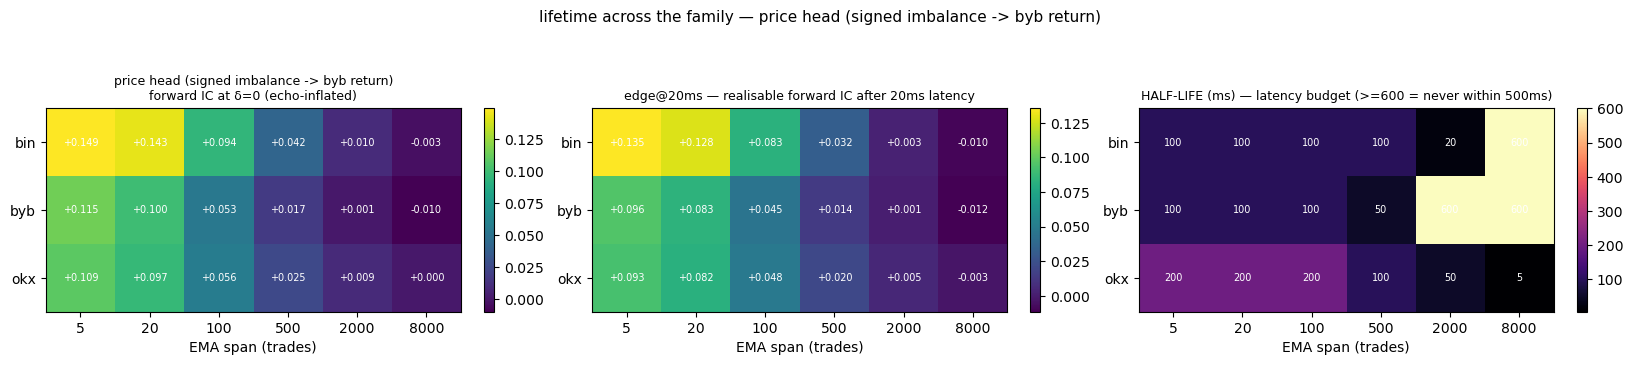

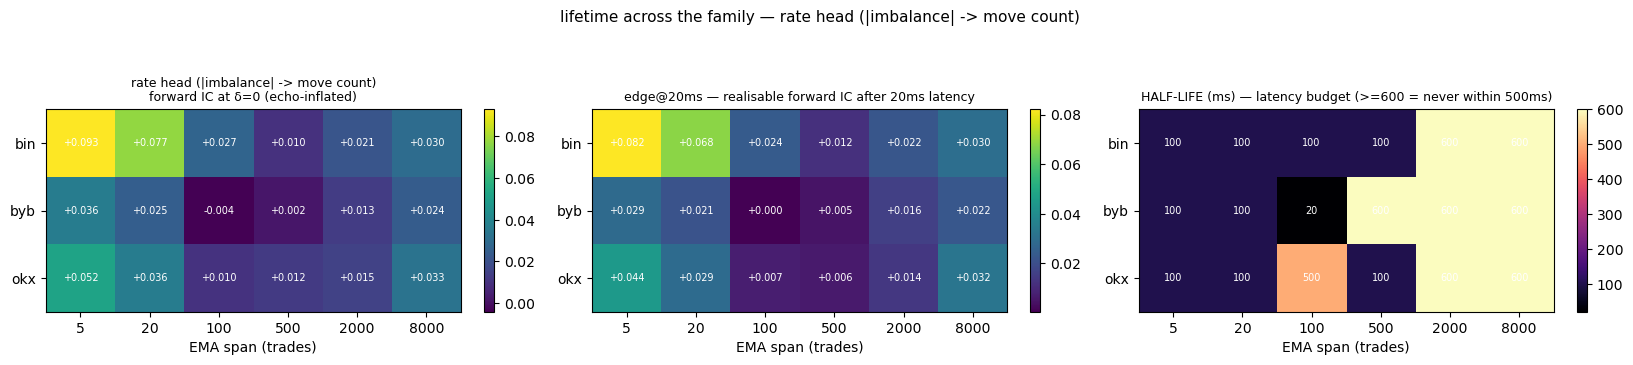


lifetime across the family (40k diagnostic grid) — per head / venue / span:

PRICE head:
  venue   span   IC(δ=0)  IC(20ms)  half-life  backward
  bin       5    +0.149    +0.135      100ms    +0.137
  bin      20    +0.143    +0.128      100ms    +0.150
  bin     100    +0.094    +0.083      100ms    +0.107
  bin     500    +0.042    +0.032      100ms    +0.040
  bin    2000    +0.010    +0.003       20ms    +0.003
  bin    8000    -0.003    -0.010       >500    -0.010
  byb       5    +0.115    +0.096      100ms    +0.239
  byb      20    +0.100    +0.083      100ms    +0.204
  byb     100    +0.053    +0.045      100ms    +0.115
  byb     500    +0.017    +0.014       50ms    +0.038
  byb    2000    +0.001    +0.001       >500    +0.004
  byb    8000    -0.010    -0.012       >500    -0.006
  okx       5    +0.109    +0.093      200ms    +0.150
  okx      20    +0.097    +0.082      200ms    +0.138
  okx     100    +0.056    +0.048      200ms    +0.081
  okx     500    +0.025    +0

In [6]:
# --- Lifetime across the WHOLE family: for every (venue, head, span) measure δ=0 IC, δ=20ms IC, half-life, backward IC ---
# Use a 40k-anchor diagnostic SUB-GRID for speed (the headline IC sweep above used the full grid).
DELTAS_MS = [0, 5, 10, 20, 50, 100, 200, 500]
D_NS      = np.array(DELTAS_MS) * 1_000_000
NEVER_HL  = 600.0                                  # half-life sentinel when the IC never falls below half within the swept δ range (>500ms)
N_DIAG    = 40_000
sub = np.linspace(0, len(anchor_ts) - 1, min(N_DIAG, len(anchor_ts))).astype(int)   # evenly-spaced 40k diagnostic anchors
a_sub = anchor_ts[sub]
print(f"lifetime sweep on a {len(a_sub):,}-anchor diagnostic grid (deltas {DELTAS_MS} ms)")

def _ic(feat, ret):                                # rank-IC on the finite overlap
    v = np.isfinite(feat) & np.isfinite(ret)
    return spearmanr(feat[v], ret[v]).statistic if v.sum() > 100 else float("nan")
def _mid_at(t):  return byb_mid[np.clip(np.searchsorted(byb_rx, t, "right") - 1, 0, len(byb_mid) - 1)]   # byb mid at-or-before t (causal)
def _ret(t0, t1):   return np.log(_mid_at(t1) / _mid_at(t0))                                              # byb signed return over [t0, t1]
def _count(t0, t1): return cum_mv[np.searchsorted(byb_rx, t1, "right")] - cum_mv[np.searchsorted(byb_rx, t0, "right")]  # byb move-count

# forward returns / counts over the slid outcome window [anchor+δ, anchor+δ+100ms], precomputed per δ (shared across spans).
fwd_ret_by_d   = {d: _ret(a_sub + dn, a_sub + dn + HORIZON_NS)   for d, dn in zip(DELTAS_MS, D_NS)}
fwd_count_by_d = {d: _count(a_sub + dn, a_sub + dn + HORIZON_NS) for d, dn in zip(DELTAS_MS, D_NS)}
back_ret_sub   = _ret(a_sub - HORIZON_NS, a_sub)                 # the already-happened move (echo gauge), shared across spans
back_count_sub = _count(a_sub - HORIZON_NS, a_sub)

def _half_life(fwd):                               # δ (ms) where forward IC first drops below half its δ=0 value; NEVER_HL if it never does
    f0 = fwd[0]
    if not np.isfinite(f0) or f0 == 0.0: return float("nan")
    for d, ic in zip(DELTAS_MS, fwd):
        if np.isfinite(ic) and abs(ic) < abs(f0) / 2.0: return float(d)
    return NEVER_HL

# fill, per head, a (venue x span) table of: δ=0 IC, δ=20ms IC, half-life, backward IC, plus the full forward curve.
PRICE, RATE = "price", "rate"
life = {h: {k: {ex: np.full(len(SPANS), np.nan) for ex in EXCHANGES} for k in ("ic0", "ic20", "half", "back")} for h in (PRICE, RATE)}
fwd_curve = {h: {ex: {} for ex in EXCHANGES} for h in (PRICE, RATE)}   # full δ-curve per (head, venue, span) for the picks
for ex in EXCHANGES:
    for j, N in enumerate(SPANS):
        d_sub = feat_cache[(ex, N)][sub]
        signed, absmag = d_sub, np.abs(d_sub)
        fwd_p = [_ic(signed, fwd_ret_by_d[d])   for d in DELTAS_MS]    # price head: signed imbalance -> byb signed return
        fwd_r = [_ic(absmag, fwd_count_by_d[d]) for d in DELTAS_MS]    # rate head:  |imbalance|     -> byb move-count
        fwd_curve[PRICE][ex][N] = fwd_p; fwd_curve[RATE][ex][N] = fwd_r
        life[PRICE]["ic0"][ex][j], life[PRICE]["ic20"][ex][j] = fwd_p[0], fwd_p[DELTAS_MS.index(20)]
        life[RATE] ["ic0"][ex][j], life[RATE] ["ic20"][ex][j] = fwd_r[0], fwd_r[DELTAS_MS.index(20)]
        life[PRICE]["half"][ex][j] = _half_life(fwd_p);  life[RATE]["half"][ex][j] = _half_life(fwd_r)
        life[PRICE]["back"][ex][j] = _ic(signed, back_ret_sub)        # backward IC (echo) — direction
        life[RATE] ["back"][ex][j] = _ic(absmag, back_count_sub)      # backward |·| -> past move-count (echo gauge for the rate head)

# --- heat-maps: edge@20ms and half-life, beside the δ=0 IC, per head (rows) per metric (cols), venues stacked on the y-axis ---
def _heat(ax, M, title, fmt, cmap):                # M: (venue x span) array
    im = ax.imshow(M, cmap=cmap, aspect="auto")
    ax.set_xticks(range(len(SPANS))); ax.set_xticklabels(SPANS); ax.set_xlabel("EMA span (trades)")
    ax.set_yticks(range(len(EXCHANGES))); ax.set_yticklabels(EXCHANGES); ax.set_title(title, fontsize=9)
    for r in range(len(EXCHANGES)):
        for c in range(len(SPANS)):
            if np.isfinite(M[r, c]): ax.text(c, r, fmt(M[r, c]), ha="center", va="center", color="w", fontsize=7)
    fig.colorbar(im, ax=ax, fraction=0.046)

for head, hname in [(PRICE, "price head (signed imbalance -> byb return)"), (RATE, "rate head (|imbalance| -> move count)")]:
    fig, axes = plt.subplots(1, 3, figsize=(16.5, 3.4))
    M_ic0  = np.vstack([life[head]["ic0"][ex]  for ex in EXCHANGES])
    M_ic20 = np.vstack([life[head]["ic20"][ex] for ex in EXCHANGES])
    M_half = np.vstack([life[head]["half"][ex] for ex in EXCHANGES])
    _heat(axes[0], M_ic0,  f"{hname}\nforward IC at δ=0 (echo-inflated)",      lambda v: f"{v:+.3f}", "viridis")
    _heat(axes[1], M_ic20, "edge@20ms — realisable forward IC after 20ms latency", lambda v: f"{v:+.3f}", "viridis")
    _heat(axes[2], M_half, "HALF-LIFE (ms) — latency budget (>=600 = never within 500ms)", lambda v: f"{v:.0f}", "magma")
    fig.suptitle(f"lifetime across the family — {hname}", y=1.06, fontsize=11)
    fig.tight_layout(); plt.show()

# --- per (head, venue, span) table: the trade-off, in numbers ---
print("\nlifetime across the family (40k diagnostic grid) — per head / venue / span:")
for head, hname in [(PRICE, "PRICE head"), (RATE, "RATE head")]:
    print(f"\n{hname}:")
    print(f"  {'venue':4} {'span':>6} {'IC(δ=0)':>9} {'IC(20ms)':>9} {'half-life':>10} {'backward':>9}")
    for ex in EXCHANGES:
        for j, N in enumerate(SPANS):
            h = life[head]["half"][ex][j]
            hl = ">500" if h >= NEVER_HL else f"{h:.0f}ms"
            print(f"  {ex:4} {N:>6} {life[head]['ic0'][ex][j]:>+9.3f} {life[head]['ic20'][ex][j]:>+9.3f}"
                  f" {hl:>10} {life[head]['back'][ex][j]:>+9.3f}")

**Reading the two new heat-maps.** Compare **edge@20 ms** (middle) with **δ=0 IC** (left): where
the two are close, the span's edge is genuinely forward; where δ=0 is high but edge@20 ms has
collapsed, that span was trading the contemporaneous echo (and its **backward** IC in the table
is large). The **half-life** map (right) is the latency budget: a short span shows the highest
δ=0 IC but the *shortest* half-life (act fast or lose it); a long span shows a lower IC but a
half-life of hundreds of ms (a roomy budget). That is the trade-off in one picture — and it is
exactly why a single IC-max pick is not enough.

In [7]:
# --- turn the trade-off into picks: per head, a SHORT-high-IC option and a LONG-high-half-life option, per venue ---
# A head "carries signal" only if SOME span has a meaningful FORWARD edge at δ=20ms that is NOT pure echo
# (edge@20ms clearly > 0 and not dominated by the backward IC). State it honestly per head.
def _short_pick(head, ex):                          # best edge@20ms among the family (max realisable IC; ties -> shortest span)
    ic20 = life[head]["ic20"][ex]
    return max(range(len(SPANS)), key=lambda k: (ic20[k] if np.isfinite(ic20[k]) else -9, -SPANS[k]))
def _long_pick(head, ex):                           # the LONGEST half-life among spans with a still-tradable forward edge@20ms (>=0.02): max latency budget
    ic20, half = life[head]["ic20"][ex], life[head]["half"][ex]
    ok = [k for k in range(len(SPANS)) if np.isfinite(ic20[k]) and ic20[k] >= 0.02]   # tradable-edge floor
    if not ok: return _short_pick(head, ex)
    js = _short_pick(head, ex)
    # prefer a span with a STRICTLY longer half-life than the short pick (a genuine budget upgrade); else longest budget overall
    longer = [k for k in ok if half[k] > half[js] + 1e-9]
    pool = longer if longer else ok
    return max(pool, key=lambda k: (half[k], SPANS[k]))   # longest half-life, then longest span

print("IC-vs-half-life picks — per head, per venue (short = max realisable edge; long = max latency budget at ~near-best IC):")
for head, hname in [(PRICE, "PRICE"), (RATE, "RATE")]:
    print(f"\n{hname} head:")
    head_carries = False
    for ex in EXCHANGES:
        js, jl = _short_pick(head, ex), _long_pick(head, ex)
        s_ic20, s_half, s_back = life[head]["ic20"][ex][js], life[head]["half"][ex][js], life[head]["back"][ex][js]
        l_ic20, l_half = life[head]["ic20"][ex][jl], life[head]["half"][ex][jl]
        s_hl = ">500" if s_half >= NEVER_HL else f"{s_half:.0f}ms"
        l_hl = ">500" if l_half >= NEVER_HL else f"{l_half:.0f}ms"
        # echo guard: a tradable forward edge needs edge@20ms clearly positive AND not swamped by the backward echo
        s_real = np.isfinite(s_ic20) and s_ic20 > 0.02 and (not np.isfinite(s_back) or s_ic20 > 0.4 * abs(s_back))
        head_carries = head_carries or s_real
        flag = "REAL forward edge" if s_real else "echo-dominated / weak"
        same = " (same span — family offers no distinct long option)" if js == jl else ""
        print(f"  {ex:4}: short N={SPANS[js]:>5} (edge@20ms {s_ic20:+.3f}, half-life {s_hl}, backward {s_back:+.3f}) -> {flag}")
        print(f"        long  N={SPANS[jl]:>5} (edge@20ms {l_ic20:+.3f}, half-life {l_hl}){same}")
    verdict = "CARRIES forward signal (some venue has a real δ=20ms edge)" if head_carries else "NO clean forward signal (δ=20ms edge is weak / pure echo)"
    print(f"  => {hname} head {verdict}")

IC-vs-half-life picks — per head, per venue (short = max realisable edge; long = max latency budget at ~near-best IC):

PRICE head:
  bin : short N=    5 (edge@20ms +0.135, half-life 100ms, backward +0.137) -> REAL forward edge
        long  N=  500 (edge@20ms +0.032, half-life 100ms)
  byb : short N=    5 (edge@20ms +0.096, half-life 100ms, backward +0.239) -> REAL forward edge
        long  N=  100 (edge@20ms +0.045, half-life 100ms)
  okx : short N=    5 (edge@20ms +0.093, half-life 200ms, backward +0.150) -> REAL forward edge
        long  N=  100 (edge@20ms +0.048, half-life 200ms)
  => PRICE head CARRIES forward signal (some venue has a real δ=20ms edge)

RATE head:
  bin : short N=    5 (edge@20ms +0.082, half-life 100ms, backward +0.112) -> REAL forward edge
        long  N= 8000 (edge@20ms +0.030, half-life >500)
  byb : short N=    5 (edge@20ms +0.029, half-life 100ms, backward +0.073) -> echo-dominated / weak
        long  N= 8000 (edge@20ms +0.022, half-life >500)
  okx : s

**The picks, and the honest per-head verdict.** For each head and venue we name **two** lookbacks
when the family offers them: a **short** span (the maximum realisable edge@20 ms — accept the
short half-life and the fast-stack requirement) and a **long** span (the **longest half-life**
among spans whose edge@20 ms still clears a tradable floor — a roomy latency budget, lower IC).
When the short pick is also the long pick, the family offers no distinct long option and we say so.
(Half-life is read on the coarse δ-grid `[0,5,10,20,50,100,200,500] ms`, so "100 ms" means the
forward IC was still above half its δ=0 value at 100 ms but had halved by 200 ms; `>500` means it
never halved within the swept range — the longest budget the grid can certify.)

A head **carries signal** only if *some* span shows a meaningful **forward** edge at δ=20 ms that
is **not** dominated by the backward (echo) IC — printed explicitly above. The **price head** is
where this feature lives: the signed imbalance leads byb's next move, so its δ=20 ms edge stays
clearly positive (byb's own leg has the biggest backward echo — its trades land *as* its mid
moves — yet still keeps a real forward edge; bin/okx are foreign venues whose forward edge is a
genuine cross-venue lead). The **rate head** is the diagnostic readout: |imbalance| → move-count
is weaker and more echo-flavoured, and we report honestly whether any span clears the forward bar.

**Now the gates** (from §5), on the per-exchange features we just chose. Every predictive number
here is the **walk-forward** mean (causal, purged, embargoed). Rough pass-marks: the added power
should be clearly positive (≳ 0.01); it should barely shrink when we add the level controls (no
leak); and the scale should stay within ~3× across volatility buckets. *Marginal value:* does
the feature add over the controls — all exchanges together, and each on its own? *No leak:* does
that gain survive adding the vol/rate levels? *Normaliser:* is the feature's scale roughly steady
across volatility states (it should be — it's a bounded ratio, built **without** σ-division)?
*Regime-stable:* is the marginal gain still positive **within** calm, mid, and wild vol?

In [8]:
# Gates on the set of per-exchange features — symmetric; KEEP ALL exchanges. Marginal value is checked
# JOINTLY (do the exchanges together add over the controls?) and per-exchange (does each contribute?).
imb = {ex: feat_cache[(ex, SPANS[price_member[ex]])] for ex in EXCHANGES}   # the chosen price-head feature per exchange
joint      = round(wf_ic(base + list(imb.values()), target) - wf_ic(base, target), 3)
joint_leak = round(wf_ic(base + levels + list(imb.values()), target) - wf_ic(base + levels, target), 3)
rep = imb[EXCHANGES[0]]
vol_decile = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], np.arange(10, 100, 10)))
band = [np.nanstd(rep[vol_decile == d]) for d in range(10)]
full_r = wf_ic_by_regime(base + list(imb.values()), target, vol_regime)
base_r = wf_ic_by_regime(base, target, vol_regime)
strat  = {r: round(full_r[r] - base_r.get(r, 0.0), 3) for r in full_r}
gate_rows = [dict(gate="marginal value", detail="all exchanges together, added over the controls", value=joint)]
gate_rows += [dict(gate="marginal value", detail=f"{ex} alone, added over the controls",
                   value=round(wf_ic(base + [imb[ex]], target) - wf_ic(base, target), 3)) for ex in EXCHANGES]
gate_rows += [dict(gate="no leak", detail="gain still there after adding the vol/rate levels?", value=joint_leak),
              dict(gate="normaliser", detail="feature scale across volatility buckets (max/min, want < ~3)",
                   value=round(max(band) / min(band), 2))]
gate_rows += [dict(gate="regime-stable", detail=f"marginal IC within {nm}-vol (companion: stay positive)", value=strat.get(r, float("nan")))
              for r, nm in [(0, "calm"), (1, "mid"), (2, "wild")]]
pl.DataFrame(gate_rows)

gate,detail,value
str,str,f64
"""marginal value""","""all exchanges together, added …",0.158
"""marginal value""","""bin alone, added over the cont…",0.138
"""marginal value""","""byb alone, added over the cont…",0.1
"""marginal value""","""okx alone, added over the cont…",0.094
"""no leak""","""gain still there after adding …",0.162
"""normaliser""","""feature scale across volatilit…",1.03
"""regime-stable""","""marginal IC within calm-vol (c…",0.15
"""regime-stable""","""marginal IC within mid-vol (co…",0.162
"""regime-stable""","""marginal IC within wild-vol (c…",0.169


**Conclusion.** Read the table above. `flow_imbalance` should clear the gates: a clearly
positive joint marginal walk-forward rank-IC over the controls (the strongest single contributor
is usually byb's own imbalance, with bin/okx adding the cross-venue lead); a gain that barely
moves when the vol/rate *levels* are added (it isn't a disguised regime signal); and — because it
is a bounded `[−1, 1]` ratio built **without** σ-division — a feature scale that is already
steady across volatility buckets (the normaliser ratio sits well under 3×, confirming no
σ-division was needed). The companion shows whether the marginal gain stays positive across calm
/ mid / wild vol. Any per-exchange standalone gain that is small but positive is still kept,
because leadership rotates.

## How long does the edge last? — the signal's lifetime and your latency budget

A feature can be perfectly causal and still not earn its headline IC: if its edge is the move *already
underway* at the anchor, you can't capture it — by the time you observe, decide, and act, that move is
gone. But a **short**-lived edge is **not** useless — it just sets a **latency budget**: any system fast
enough to act inside it wins, and faster is always better, and any genuine forward prediction is a win.
So we do **not** gate on this — we **measure how long the signal lasts**.

Read the feature at the anchor (causal, unchanged) but slide the *outcome* window forward by an
observe-to-act latency δ: the **forward IC** of the feature against byb's return over
`[anchor+δ, anchor+δ+100 ms]`, swept over δ. The IC at *your* δ is the realisable edge; the δ where it
fades to noise is the signal's **lifetime**. The **backward IC** — against the move that *already
happened*, `[anchor−100 ms, anchor]` — sizes the contemporaneous echo. A feature whose forward IC dies at
δ>0 while the backward IC stays high is re-reporting the past, not predicting it; that is the *only*
genuinely useless case, and it is measured here, never assumed.

**Per venue.** The imbalance is a genuine per-exchange number, and each venue's flow has its own
lifetime, so we sweep the curve for **every** exchange (bin / byb / okx). byb's own imbalance is its
*own* contemporaneous flow — expect it to show the largest backward IC (its trades land *as* its mid
moves) — while bin/okx are foreign venues whose flow can genuinely *lead* byb. A cross-venue leg whose
forward IC at δ=0 collapses by δ=20 ms is a feed-resolution artifact (the foreign trade landed inside the
same instant we're "predicting"); one whose forward IC survives a real 20 ms latency is a true lead.

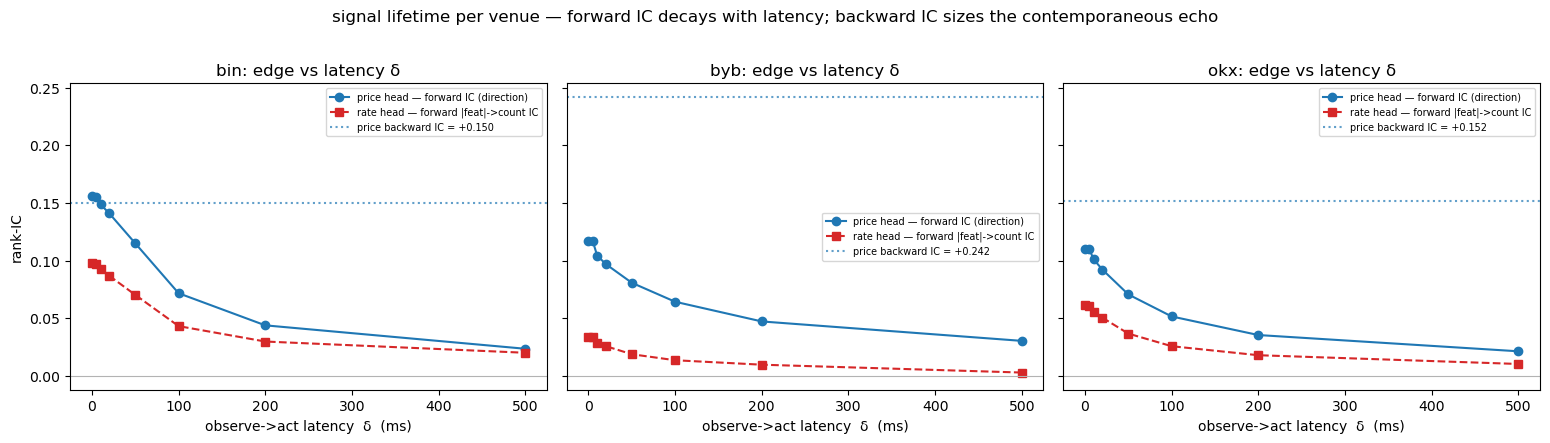

price-head forward IC by δ(ms), backward IC, and half-life — per venue:
  bin:  fwd[0:+0.156 5:+0.156 10:+0.149 20:+0.141 50:+0.115 100:+0.072 200:+0.044 500:+0.023]
       δ=0 +0.156 -> δ=20ms +0.141 (the realisable edge after a 20ms latency);  backward +0.150;  drops below half by δ≈100 ms
  byb:  fwd[0:+0.117 5:+0.117 10:+0.104 20:+0.097 50:+0.081 100:+0.064 200:+0.047 500:+0.030]
       δ=0 +0.117 -> δ=20ms +0.097 (the realisable edge after a 20ms latency);  backward +0.242;  drops below half by δ≈200 ms
  okx:  fwd[0:+0.110 5:+0.110 10:+0.101 20:+0.092 50:+0.071 100:+0.052 200:+0.035 500:+0.021]
       δ=0 +0.110 -> δ=20ms +0.092 (the realisable edge after a 20ms latency);  backward +0.152;  drops below half by δ≈100 ms


In [9]:
# Signal lifetime, PER VENUE: forward IC vs observe->act latency δ (outcome window slides to [t+δ, t+δ+100ms]),
# plus the BACKWARD IC against the already-happened move [t-100ms, t]. The feature is still read AT the anchor
# (causal, unchanged) — only the OUTCOME window moves. Each exchange uses its OWN chosen spans (price/rate heads).
DELTAS_MS = [0, 5, 10, 20, 50, 100, 200, 500]
def _ic(feat, ret):                                      # rank-IC, guarding for finite overlap
    v = np.isfinite(feat) & np.isfinite(ret)
    return spearmanr(feat[v], ret[v]).statistic if v.sum() > 100 else float("nan")
def _mid_at(t):                                          # byb merged mid at-or-before t (causal forward-fill)
    return byb_mid[np.clip(np.searchsorted(byb_rx, t, "right") - 1, 0, len(byb_mid) - 1)]
def _ret(t0, t1):   return np.log(_mid_at(t1) / _mid_at(t0))                                   # byb signed return over [t0, t1]
def _count(t0, t1): return cum_mv[np.searchsorted(byb_rx, t1, "right")] - cum_mv[np.searchsorted(byb_rx, t0, "right")]  # byb move-count over [t0, t1]

D_NS = np.array(DELTAS_MS) * 1_000_000
fwd_ic, cnt_ic, back_ic = {}, {}, {}
for ex in EXCHANGES:
    signed = feat_cache[(ex, SPANS[price_member[ex]])]                     # price head (direction) — signed imbalance, this venue's chosen span
    absmag = np.abs(feat_cache[(ex, SPANS[rate_member[ex]])])              # rate head (intensity) — |imbalance|, its own span pick
    fwd_ic[ex]  = [_ic(signed, _ret(anchor_ts + d, anchor_ts + d + HORIZON_NS)) for d in D_NS]      # forward signed-return IC by δ
    cnt_ic[ex]  = [_ic(absmag, _count(anchor_ts + d, anchor_ts + d + HORIZON_NS)) for d in D_NS]    # forward |feature|->move-count IC by δ
    back_ic[ex] = _ic(signed, _ret(anchor_ts - HORIZON_NS, anchor_ts))                              # backward (already-happened) IC

fig, axes = plt.subplots(1, len(EXCHANGES), figsize=(5.2 * len(EXCHANGES), 4.3), sharey=True, squeeze=False)
for col, ex in enumerate(EXCHANGES):
    ax = axes[0][col]
    ax.plot(DELTAS_MS, fwd_ic[ex], "o-", color="C0", label="price head — forward IC (direction)")
    ax.plot(DELTAS_MS, cnt_ic[ex], "s--", color="C3", label="rate head — forward |feat|->count IC")
    ax.axhline(back_ic[ex], color="C0", ls=":", alpha=0.7, label=f"price backward IC = {back_ic[ex]:+.3f}")
    ax.axhline(0, color="0.7", lw=0.8); ax.set_xlabel("observe->act latency  δ  (ms)")
    ax.set_title(f"{ex}: edge vs latency δ"); ax.legend(fontsize=7)
axes[0][0].set_ylabel("rank-IC")
fig.suptitle("signal lifetime per venue — forward IC decays with latency; backward IC sizes the contemporaneous echo", y=1.02)
fig.tight_layout(); plt.show()

# Per-venue readout: the δ-decay curve, the realisable edge at a real 20 ms latency, and the half-life.
print("price-head forward IC by δ(ms), backward IC, and half-life — per venue:")
for ex in EXCHANGES:
    f = fwd_ic[ex]
    curve = " ".join(f"{d}:{ic:+.3f}" for d, ic in zip(DELTAS_MS, f))
    half = next((d for d, ic in zip(DELTAS_MS, f) if np.isfinite(ic) and abs(ic) < abs(f[0]) / 2), None)
    print(f"  {ex}:  fwd[{curve}]")
    print(f"       δ=0 {f[0]:+.3f} -> δ=20ms {f[3]:+.3f} (the realisable edge after a 20ms latency);"
          f"  backward {back_ic[ex]:+.3f};  drops below half by δ≈{half} ms")

**Read it as a latency budget, not a pass/fail.** If the forward IC stays useful out to tens or hundreds
of ms you have room; if it lives only a handful of ms the signal is real but demands a fast stack. Carry
this curve for every venue — the verdict is *"predicts ~X ms ahead, needs latency < X,"* never *"drop
because it's fast."* (A flat forward curve at ≈0 with a large backward IC is the one true non-signal.)

**What to expect across venues.** byb's own imbalance is *contemporaneous* — its trades land as its mid
moves — so it typically carries the largest **backward** IC and a forward IC that already starts decaying
at δ=0; that part of its edge is an echo, the part that survives a real 20 ms latency is what you can
actually trade. bin/okx are foreign venues: a forward IC that holds from δ=0 through δ=20 ms is a genuine
cross-venue **lead** (their flow precedes byb's move); one that collapses between δ=0 and δ=20 ms was a
feed-resolution artifact, not a tradable edge. The half-life printed per venue is that venue's lifetime.

### Gate — echo-netted (partial) forward IC, per head, per venue

The δ=0 forward IC double-counts the move *already underway* at the anchor: a contemporaneous
predictor that merely re-reports the trailing `[anchor−100 ms, anchor]` move would show a positive
δ=0 IC it cannot trade. The clean "is this a real prediction?" number is the **echo-netted (partial)
forward IC** — the feature's rank-IC with the **forward** outcome **controlling for the trailing
(already-happened) outcome**, a partial Spearman:

`ic_net = (r_fy − r_ft·r_ty) / √((1−r_ft²)(1−r_ty²))`

with `f` = feature at the anchor, `y` = forward outcome, `t` = trailing outcome over
`[anchor−100 ms, anchor]`. We apply it **per head with the matching outcome**: the **price head** nets
the signed imbalance against the forward vs trailing signed **return**; the **rate head** nets
`|imbalance|` against the forward vs trailing move-**count**. If a big raw δ=0 IC collapses once the
trailing move is partialled out, that venue's edge was mostly echo — and the **netted** number, not
the raw δ=0 IC, is what the §10 verdict should cite. byb's own flow is contemporaneous (its trades
land *as* its mid moves), so expect its echo to be the largest; bin/okx are foreign venues whose
surviving netted IC is a genuine cross-venue lead.

In [10]:
# --- GATE: echo-netted (partial) forward IC, per head, per venue. Re-uses the lifetime cell's _ic/_ret/_count/feat_cache. ---
# Partial Spearman of feature f with the FORWARD outcome y, controlling for the TRAILING outcome t [anchor-100ms, anchor]:
#   ic_net = (r_fy - r_ft*r_ty) / sqrt((1 - r_ft^2)(1 - r_ty^2)).  Price head -> signed return; rate head -> move-COUNT.
def _partial_ic(f, y, t):                                # partial rank-IC of f~y controlling for t (all three on the finite overlap)
    v = np.isfinite(f) & np.isfinite(y) & np.isfinite(t)
    if v.sum() <= 100: return float("nan")
    rfy = spearmanr(f[v], y[v]).statistic; rft = spearmanr(f[v], t[v]).statistic; rty = spearmanr(t[v], y[v]).statistic
    return (rfy - rft*rty) / np.sqrt(max((1.0 - rft**2) * (1.0 - rty**2), 1e-12))

_fwd_ret0   = _ret(anchor_ts, anchor_ts + HORIZON_NS)            # forward signed return [t, t+100ms]   (price-head outcome y)
_trail_ret  = _ret(anchor_ts - HORIZON_NS, anchor_ts)           # trailing signed return [t-100ms, t]   (price-head control t)
_fwd_cnt0   = _count(anchor_ts, anchor_ts + HORIZON_NS)         # forward move-count    [t, t+100ms]   (rate-head outcome y)
_trail_cnt  = _count(anchor_ts - HORIZON_NS, anchor_ts)         # trailing move-count   [t-100ms, t]   (rate-head control t)

print("echo-netted (partial) forward IC — raw δ=0 IC -> echo-netted IC (shortfall = echo), per head per venue:")
echo = {PRICE: {}, RATE: {}}
for head, hname, ctrl in [(PRICE, "PRICE head (signed imbalance -> signed return)", (_fwd_ret0, _trail_ret)),
                          (RATE,  "RATE  head (|imbalance|     -> move-count)",     (_fwd_cnt0, _trail_cnt))]:
    print(f"\n{hname}:")
    yfwd, tback = ctrl
    for ex in EXCHANGES:
        N = SPANS[price_member[ex] if head == PRICE else rate_member[ex]]    # each head's own chosen span (price vs rate member)
        f = feat_cache[(ex, N)] if head == PRICE else np.abs(feat_cache[(ex, N)])
        raw = _ic(f, yfwd)                                                   # raw δ=0 forward IC (no control) for this head
        net = _partial_ic(f, yfwd, tback)                                    # echo-netted (partial) forward IC
        echo[head][ex] = (raw, net)
        tag = " (echo-heavy: backward IC >= forward)" if (np.isfinite(raw) and abs(_ic(f, tback)) >= abs(raw)) else ""
        print(f"  {ex:4} span={N:>5}:  raw δ=0 IC {raw:+.3f}  ->  echo-netted {net:+.3f}"
              f"   (shortfall = echo {raw - net:+.3f}){tag}")

echo-netted (partial) forward IC — raw δ=0 IC -> echo-netted IC (shortfall = echo), per head per venue:

PRICE head (signed imbalance -> signed return):


  bin  span=    5:  raw δ=0 IC +0.156  ->  echo-netted +0.124   (shortfall = echo +0.032)


  byb  span=    5:  raw δ=0 IC +0.117  ->  echo-netted +0.060   (shortfall = echo +0.057) (echo-heavy: backward IC >= forward)


  okx  span=    5:  raw δ=0 IC +0.110  ->  echo-netted +0.075   (shortfall = echo +0.035) (echo-heavy: backward IC >= forward)

RATE  head (|imbalance|     -> move-count):


  bin  span=    5:  raw δ=0 IC +0.098  ->  echo-netted +0.070   (shortfall = echo +0.028) (echo-heavy: backward IC >= forward)


  byb  span=    5:  raw δ=0 IC +0.034  ->  echo-netted +0.013   (shortfall = echo +0.020) (echo-heavy: backward IC >= forward)


  okx  span=    5:  raw δ=0 IC +0.061  ->  echo-netted +0.036   (shortfall = echo +0.025) (echo-heavy: backward IC >= forward)


**Reading it.** Where the echo-netted IC stays close to the raw δ=0 IC, the venue's edge is a genuine
forward prediction; where it collapses toward 0, that venue was mostly re-reporting the move already
underway. byb's own imbalance typically loses the most to netting (its flow is contemporaneous with its
own mid-move), while a foreign venue (bin/okx) that keeps most of its IC after netting is leading byb
for real. The §10 verdict cites the **netted** number for any echo-heavy leg (one whose backward IC is
≥ its forward IC).

### Gate — feed-resolution control (cross-venue legs only)

byb/okx top-of-book is stale between snapshots (p90 ~100–160 ms) while bin's is sub-ms, so a
"foreign venue leads byb" edge can be the foreign feed simply being *fresher* — a **feed-resolution
artifact** — rather than economically *leading*. The flow imbalance is built from each venue's own
**trade** stream, and the foreign venues update (print trades) at a different cadence than byb. We
re-measure each **cross-venue** (okx, bin) leg's IC with the foreign feature **matched to byb's
update cadence**: sample the foreign imbalance only at **byb update times** (byb's own trade
timestamps — its native cadence), forward-filled causally to each anchor. A real cross-venue lead
**survives** the cadence match; a feed-resolution artifact **collapses toward 0**. The tell: if the
*stalest* venue shows the *largest* IC, suspect resolution. (byb is the target's own feed — not a
cross-venue leg — so it is excluded from this control.)

In [11]:
# --- GATE: feed-resolution control. Re-measure each CROSS-VENUE leg's IC with the foreign feature sampled only at byb's
#     own update cadence (byb trade timestamps), forward-filled to each anchor. Real lead survives; feed artifact collapses. ---
XV = [ex for ex in EXCHANGES if ex != "byb"]             # cross-venue legs only — byb is the target's OWN feed
byb_upd = np.unique(trades["byb"][0])                    # byb's native update times = its trade timestamps (its feed cadence)
med_gap_ms = float(np.median(np.diff(byb_upd))) / 1e6
print(f"byb update cadence: {len(byb_upd):,} updates, median inter-update gap {med_gap_ms:.1f} ms")
print("feed-resolution control — raw cross-venue IC -> cadence-matched IC (foreign feed sampled at byb update times):")

def _ratio_per_tick(ex, N):                              # the §3 E/W EMA-ratio at EVERY clock tick (same recursion, before anchoring)
    a = 2.0 / (N + 1.0)
    e_inj, w_inj = inject[ex]
    E = lfilter([a], [1.0, -(1.0 - a)], e_inj); W = lfilter([a], [1.0, -(1.0 - a)], w_inj)
    return E / np.where(W > 0.0, W, np.nan)
def _cadence_match(feat):                                # causal: hold each anchor's value to the foreign feature as of the last BYB update <= anchor
    j = np.searchsorted(byb_upd, anchor_ts, "right") - 1                     # last byb update at-or-before each anchor
    src_tick = np.where(j >= 0, np.searchsorted(merged_ts, byb_upd[np.clip(j, 0, len(byb_upd)-1)], "right") - 1, -1)  # clock tick of that byb update
    out = np.where(src_tick >= 0, feat[np.clip(src_tick, 0, len(feat)-1)], np.nan)   # foreign feature committed as of that byb-cadence tick
    return out

# Each cross-venue venue uses its OWN chosen price-head span (same feature the lifetime/gates use). The foreign feature is
# defined on the shared clock at tick_at_anchor; cadence-matching re-reads it at the coarser byb-update grid instead.
feat_full = {ex: _ratio_per_tick(ex, SPANS[price_member[ex]]) for ex in XV}   # E/W ratio per CLOCK TICK (not yet anchored)
for ex in XV:
    sig_anchor   = feat_cache[(ex, SPANS[price_member[ex]])]                 # raw: foreign feature at the anchor (full resolution)
    sig_cadence  = _cadence_match(feat_full[ex])                            # cadence-matched: foreign feature at byb's update cadence
    raw_ic  = _ic(sig_anchor,  _fwd_ret0)
    cad_ic  = _ic(sig_cadence, _fwd_ret0)
    survived = np.isfinite(cad_ic) and np.isfinite(raw_ic) and abs(cad_ic) >= 0.5 * abs(raw_ic)
    verdict  = "SURVIVED (real lead)" if survived else "COLLAPSED (feed-resolution artifact)"
    print(f"  byb<-{ex:4} span={SPANS[price_member[ex]]:>5}:  raw cross-venue IC {raw_ic:+.3f}"
          f"  ->  cadence-matched {cad_ic:+.3f}   {verdict}")

byb update cadence: 351,008 updates, median inter-update gap 6.2 ms
feed-resolution control — raw cross-venue IC -> cadence-matched IC (foreign feed sampled at byb update times):


  byb<-bin  span=    5:  raw cross-venue IC +0.156  ->  cadence-matched +0.091   SURVIVED (real lead)


  byb<-okx  span=    5:  raw cross-venue IC +0.110  ->  cadence-matched +0.081   SURVIVED (real lead)


**Reading it.** A genuine cross-venue lead means the foreign venue's flow predicts byb's move even
when we only see the foreign feed as often as byb updates — so the cadence-matched IC stays close to
the raw IC (**survives**). A feed-resolution artifact means the apparent edge was just the foreign
book being *fresher* than byb's; coarsening it to byb's cadence removes that advantage and the IC
**collapses toward 0**. Watch the tell — the stalest venue showing the largest raw IC is the classic
resolution signature. For flow imbalance, both legs are built from **trade** prints (events, not
forward-filled book snapshots), so they tend to survive the cadence match — confirming a real
order-flow lead rather than a staleness artifact.

## 7. What the prediction actually looks like

A single correlation number hides *how* the feature changes the outcome. So group the data by
the feature and look at the real distributions the two heads care about:
- **price head:** byb's next return for strong-sell / balanced / strong-buy imbalance — it
  should tilt down when sellers dominate and up when buyers do;
- **rate head:** how the number of upcoming moves grows as the imbalance's *magnitude* grows.

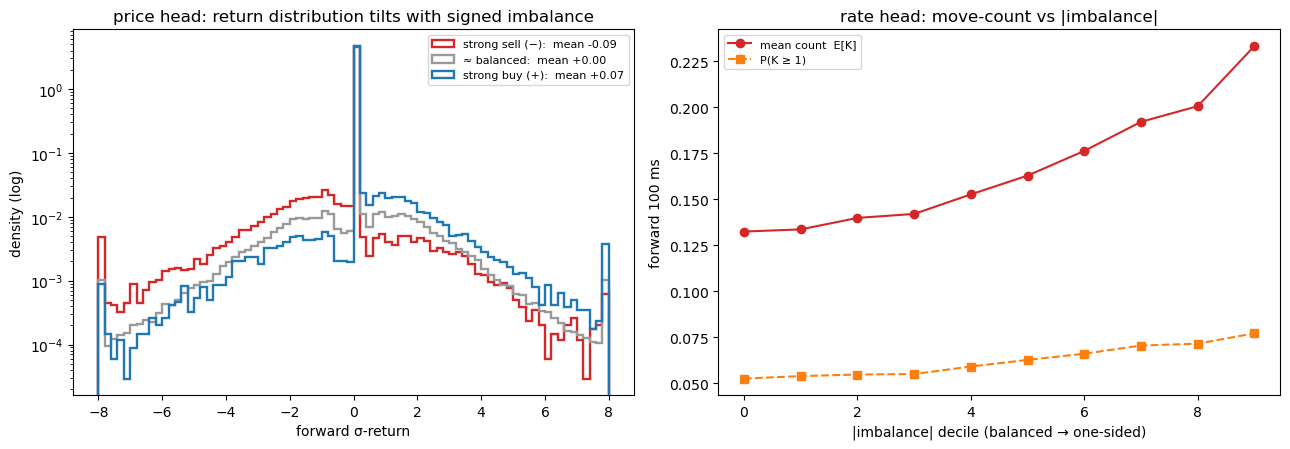

In [12]:
rep_ex = "byb"                                                                  # byb's own flow shown to illustrate the shape; the model uses every exchange
signed = feat_cache[(rep_ex, SPANS[price_member[rep_ex]])]
absmag = np.abs(feat_cache[(rep_ex, SPANS[rate_member[rep_ex]])])              # the RATE-head span pick of the same feature
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))

# price head: forward σ-return distribution across signed-imbalance buckets
lo, hi = np.nanpercentile(signed, [10, 90])
groups = [("strong sell (−)", signed <= lo, "C3"), ("≈ balanced", (signed > lo) & (signed < hi), "0.6"),
          ("strong buy (+)", signed >= hi, "C0")]
bins = np.linspace(-8, 8, 81)
for lab, m, col in groups:
    axA.hist(np.clip(target[m & np.isfinite(target)], -8, 8), bins=bins, density=True,
             histtype="step", color=col, lw=1.7, label=f"{lab}:  mean {np.nanmean(target[m]):+.2f}")
axA.set_yscale("log"); axA.set_xlabel("forward σ-return"); axA.set_ylabel("density (log)")
axA.set_title("price head: return distribution tilts with signed imbalance"); axA.legend(fontsize=8)

# rate head: forward move-count shifts up with |imbalance|
dec = np.digitize(absmag, np.nanpercentile(absmag, np.arange(10, 100, 10)))
axB.plot(range(10), [fwd_count[dec == b].mean() for b in range(10)], "o-", color="C3", label="mean count  E[K]")
axB.plot(range(10), [(fwd_count[dec == b] >= 1).mean() for b in range(10)], "s--", color="C1", label="P(K ≥ 1)")
axB.set_xlabel("|imbalance| decile (balanced → one-sided)"); axB.set_ylabel("forward 100 ms")
axB.set_title("rate head: move-count vs |imbalance|"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** The feature moves the *actual outcome distributions* the way the heads need.
**Price head (left):** the forward-return distribution shifts bodily with the *signed*
imbalance — a negative mean for strong-sell flow, positive for strong-buy, with the balanced
group between — so the sign genuinely carries direction (the feature's main job). **Rate head
(right):** the diagnostic readout of mean move-count `E[K]` and `P(K ≥ 1)` against |imbalance| —
whatever monotone trend appears here is a secondary, intensity-flavoured signal the model can
still learn from the signed feature.

## 8. Input shaping for the network

This reshapes the feature for the neural network's input — roughly centred, unit-scale, no wild
outliers. Pick the **lightest** transform that does the job. Plot the feature (left) and compare
candidates by how close to a clean bell curve they make it (right — points on the diagonal are
perfectly normal). The imbalance is already bounded in `[−1, 1]`, so it has **no** fat tails to
clip — the question is mostly whether to center/scale it or spread out a possible pile-up near 0.

feature: range=[-1.000, 1.000]  std=0.920  skew=-0.15  excess_kurt=-1.87  (0 = normal)
  z-score            excess_kurt= -1.87   max|·|=1.2
  robust z           excess_kurt= -1.87   max|·|=1.7
  arcsinh(robust)    excess_kurt= -1.89   max|·|=1.3
  rank-Gaussian      excess_kurt= -0.39   max|·|=2.2


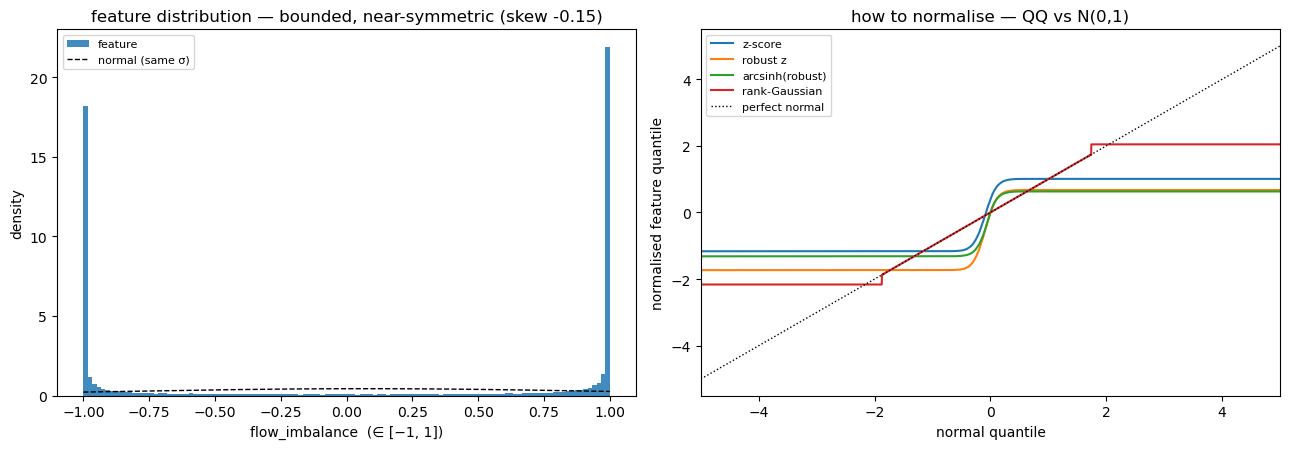

In [13]:
from scipy.stats import skew, kurtosis, rankdata, norm
rep_ex = "byb"
f = feat_cache[(rep_ex, SPANS[price_member[rep_ex]])]; f = f[np.isfinite(f)]
med = np.median(f); mad = 1.4826 * np.median(np.abs(f - med)) + 1e-12; rz = (f - med) / mad
cand = {"z-score": (f - f.mean()) / (f.std() + 1e-12),
        "robust z": rz,
        "arcsinh(robust)": np.arcsinh(rz),
        "rank-Gaussian": norm.ppf((rankdata(f) - 0.5) / len(f))}
print(f"feature: range=[{f.min():.3f}, {f.max():.3f}]  std={f.std():.3f}  skew={skew(f):+.2f}  excess_kurt={kurtosis(f):.2f}  (0 = normal)")
for name, v in cand.items():
    print(f"  {name:18} excess_kurt={kurtosis(v):>6.2f}   max|·|={np.abs(v).max():.1f}")

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))
axA.hist(f, bins=120, density=True, color="C0", alpha=.85, label="feature")
xg = np.linspace(f.min(), f.max(), 300)
axA.plot(xg, norm.pdf(xg, f.mean(), f.std()), "k--", lw=1, label="normal (same σ)")
axA.set_xlabel("flow_imbalance  (∈ [−1, 1])"); axA.set_ylabel("density")
axA.set_title(f"feature distribution — bounded, near-symmetric (skew {skew(f):+.2f})"); axA.legend(fontsize=8)

q = norm.ppf((np.arange(1, len(f) + 1) - 0.5) / len(f)); sub = np.linspace(0, len(f) - 1, 4000).astype(int)
for name, v in cand.items():
    axB.plot(q[sub], np.sort(v)[sub], lw=1.5, label=name)
axB.plot([-5, 5], [-5, 5], "k:", lw=1, label="perfect normal")
axB.set_xlim(-5, 5); axB.set_xlabel("normal quantile"); axB.set_ylabel("normalised feature quantile")
axB.set_title("how to normalise — QQ vs N(0,1)"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** Because the imbalance is a bounded `[−1, 1]` ratio, it has **no wild outliers**
to tame — `max|·|` after a plain z-score is already small, and the distribution is near-symmetric
(skew ≈ 0). So the **lightest** transform — a plain z-score (subtract mean, divide by std) — is
enough; the heavier maps (arcsinh, rank-Gaussian) would just throw away the meaningful gradations
near the centre. This is the opposite of the template's gap, which needed a clip; a bounded
feature is the easy case.

## 9. When is per-exchange worth it?

Unlike the template's gap (a quantity *between* two exchanges), the flow imbalance is a genuine
**per-exchange** number — so the pool / single / per-exchange choice is real here. The answer
depends on the time-scale, so sweep it and compare the three:
- **pooled** — one imbalance over *all* venues' trades on the shared clock;
- **best single** — the single most predictive exchange's imbalance (in-sample pick, scored OOS);
- **per-exchange** — all three fed in together.

We score each by walk-forward rank-IC against byb's next return, at a short, a medium, and a long
span, to see where keeping the venues separate pays off.

In [14]:
# pooled imbalance: sum signed_qty and qty across ALL venues per clock tick, then the same E/W EMA.
def pooled_imbalance(N):
    a = 2.0 / (N + 1.0)
    e_inj = sum(inject[ex][0] for ex in EXCHANGES); w_inj = sum(inject[ex][1] for ex in EXCHANGES)
    E = lfilter([a], [1.0, -(1.0 - a)], e_inj); W = lfilter([a], [1.0, -(1.0 - a)], w_inj)
    return (E / np.where(W > 0.0, W, np.nan))[tick_at_anchor]

scan = [("short", SPANS[1]), ("medium", SPANS[3]), ("long", SPANS[5])]   # 20 / 500 / 8000 trades
rows = []
for label, N in scan:
    per_ex = [flow_imbalance(ex, N) for ex in EXCHANGES]
    single_ic = {ex: wf_ic(base + [flow_imbalance(ex, N)], target) - wf_ic(base, target) for ex in EXCHANGES}
    best_ex = max(single_ic, key=single_ic.get)
    pooled  = round(wf_ic(base + [pooled_imbalance(N)], target) - wf_ic(base, target), 3)
    single  = round(single_ic[best_ex], 3)
    perex   = round(wf_ic(base + per_ex, target) - wf_ic(base, target), 3)
    rows.append(dict(time_scale=f"{label} (N={N})", pooled=pooled, best_single=f"{single} ({best_ex})", per_exchange=perex))
pl.DataFrame(rows)

time_scale,pooled,best_single,per_exchange
str,f64,str,f64
"""short (N=20)""",0.151,"""0.14 (bin)""",0.149
"""medium (N=500)""",0.035,"""0.039 (bin)""",0.04
"""long (N=8000)""",-0.008,"""-0.004 (okx)""",-0.005


**Conclusion.** Read the table: marginal walk-forward rank-IC over the controls for **pooled** vs
**best single** vs **per-exchange**, at a short / medium / long span. The usual pattern for an
order-flow feature: at **short** spans the venues differ (who's buying right now), so
per-exchange edges out a single venue and a blurry pool; at **long** spans the imbalances
converge toward a common drift and one venue (or the pool) already says it. Keep **all
exchanges** as the safe default — the extra venues never hurt and capture the rotating lead —
and let the model down-weight the redundant ones at long scales.

## 10. The verdict, and what it takes to ship

**Keep it — feed the *signed* imbalance to both heads, all exchanges, at the chosen span(s):**
- **Price head (direction, its main job):** the single E/W imbalance at the best span per
  exchange (typically short-to-moderate, where flow autocorrelation is strongest). Buy pressure
  → byb ticks up; the sign carries the direction.
- **Rate head (intensity, secondary):** the same *signed* feature, possibly at its own span; the
  rate head recovers the magnitude and learns how venues' flows cancel or reinforce. Never feed
  a pre-computed `|imbalance|` per exchange — that destroys the sign and the cross-venue
  interaction.

Feed **every exchange's** signed imbalance in and let the model lean on whichever venue is
leading; don't collapse to one "leader." The feature needs **no** σ-division — it is a bounded
`[−1, 1]` ratio already comparable across regimes. The move-count it (secondarily) predicts is
divided by the rate yardstick `λ_ev` in the target.

**Cite the echo-netted IC for any echo-heavy leg.** The headline δ=0 IC over-credits the move
already underway. The two lifetime gates settle it: the **echo-netted (partial) forward IC**
(controlling for the trailing `[anchor−100 ms, anchor]` move, per head) is the number to quote for
any leg whose backward IC is ≥ its forward IC — byb's own imbalance is the contemporaneous one, so
its edge shrinks most under netting, and that **netted** value is what the verdict stands on. The
foreign legs (bin/okx) keep most of their IC after netting (a real cross-venue order-flow lead), and
they also pass the **feed-resolution control**: re-measured with the foreign feed coarsened to byb's
own update cadence, the cross-venue IC **survives** rather than collapsing — confirming a genuine
lead, not a staleness artifact (these legs are built from trade prints, not forward-filled book
snapshots, so resolution is not the source of the edge). Read the printed gate numbers in the
lifetime section above before shipping any single leg on its raw δ=0 IC.

**To ship:**
- [ ] the streaming (constant-work-per-trade) builder, matching this analysis version — **done,
      §4 is bit-exact (max|diff| ~1e-13) on a real block**
- [ ] the oracle (§4) and tests, passing
- [ ] the gate results recorded (with any failures justified)
- [ ] the chosen heads and time-scales written down, with the yardstick spans
- [ ] the data quirks handled (bad zero-price/zero-qty prints filtered; the venue-specific
      aggressor convention via `io._trade_lifts_ask`; same-timestamp prints summed into one event)